# Question 3

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score
)


In [2]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split

# Load dataset
spambase = fetch_ucirepo(id=94)
X = spambase.data.features
y = spambase.data.targets.iloc[:, 0]   # make y 1D

# Same split used in Problem 1
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [3]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    err = 1 - acc
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    return {
        "accuracy": acc,
        "error": err,
        "precision": prec,
        "recall": rec
    }

In [4]:
#cross validation for kNN

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 50)
cv_rows = []

for k in k_values:
    knn_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors = k))
    ])
    scores = cross_validate(
        knn_pipe,
        X_train,
        y_train,
        cv = cv,
        scoring = ["accuracy", "precision", "recall"],
        return_train_score = False
    )

    avg_acc = np.mean(scores["test_accuracy"])
    avg_err = 1 - avg_acc
    avg_prec = np.mean(scores["test_precision"])
    avg_rec = np.mean(scores["test_recall"])

    cv_rows.append({
        "k": k,
        "cv_accuracy": avg_acc,
        "cv_error": avg_err,
        "cv_precision": avg_prec,
        "cv_recall": avg_rec
    })

cv_results = pd.DataFrame(cv_rows)
print("Cross-validation results for kNN:")
print(cv_results)
best_k = cv_results.loc[cv_results["cv_error"].idxmin(), "k"]

Cross-validation results for kNN:
    k  cv_accuracy  cv_error  cv_precision  cv_recall
0   1     0.904638  0.095362      0.882587   0.874189
1   3     0.907826  0.092174      0.889861   0.874200
2   5     0.904638  0.095362      0.890246   0.864641
3   7     0.907826  0.092174      0.896489   0.866100
4   9     0.902319  0.097681      0.892186   0.855798
5  11     0.902609  0.097391      0.896304   0.851389
6  15     0.897681  0.102319      0.899450   0.833729
7  21     0.889275  0.110725      0.897164   0.812394


Based on the results, the best k values were k = 3, 7 where the cross validation errors were both 0.092174.

In [6]:
#train all three classifiers

logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter = 5000))
])

lda_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors = int(best_k)))
])

models = {
    "Logistic Regression": logreg_model,
    "LDA": lda_model,
    "kNN": knn_model
}

metric_rows = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_metrics = compute_metrics(y_train, y_train_pred)
    test_metrics = compute_metrics(y_test, y_test_pred)

    metric_rows.append({
        "model": model_name,
        "train_accuracy" : train_metrics["accuracy"],
        "train_error" : train_metrics["error"],
        "train_precision": train_metrics["precision"],
        "train_recall" : train_metrics["recall"],
        "test_accuracy": test_metrics["accuracy"],
        "test_error" : test_metrics["error"],
        "test_precision" : test_metrics["precision"],
        "test_recall": test_metrics["recall"]
    })

metrics_df = pd.DataFrame(metric_rows)
print("\nTraining and testing metrics:")
print(metrics_df)


Training and testing metrics:
                 model  train_accuracy  train_error  train_precision  \
0  Logistic Regression        0.928986     0.071014         0.927803   
1                  LDA        0.891014     0.108986         0.918298   
2                  kNN        0.950435     0.049565         0.943284   

   train_recall  test_accuracy  test_error  test_precision  test_recall  
0      0.888889       0.927889    0.072111        0.930394     0.883260  
1      0.793966       0.884448    0.115552        0.910486     0.784141  
2      0.930096       0.901825    0.098175        0.881432     0.867841  


The best performing model is logistic regression. It has the. highest testing accuracy (0.9279), the lowest testing error (0.0721), the highest testing precision (0.9304), and a strong testing recall (0.8833). The worst performing model is LDA, with the lowest testing accuracy (0.8844), the highest testing error (0.1156), and the lowest testing recall (0.7841). One pattern I noticed is that logistic regression generalizes the best, because its training and testing metrics are very close. I also noticed that kNN has the highest training performance but lower testing performance than logistic regression. This might suggest that kNN could be fitting the training data more closely and generalizing worse than logistic regression.


AUC for Logistic Regression = 0.9727529563453189


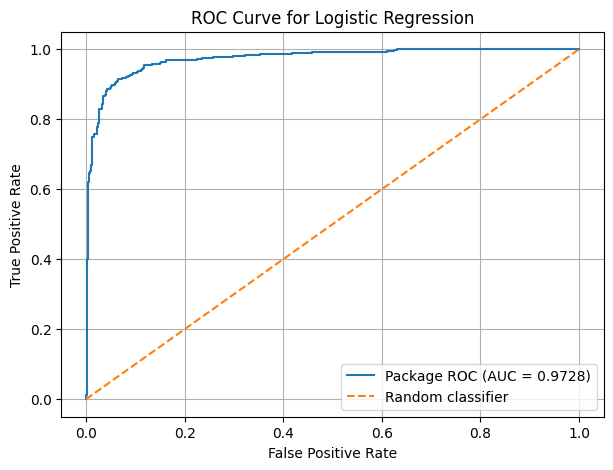

In [7]:
#ROC curve for logistic regression

logreg_model.fit(X_train, y_train)
y_test_prob = logreg_model.predict_proba(X_test)[:, 1]

fpr_pkg, tpr_pkg, thresholds_pkg = roc_curve(y_test, y_test_prob)
auc_value = roc_auc_score(y_test, y_test_prob)

print("\nAUC for Logistic Regression =", auc_value)

plt.figure(figsize = (7, 5))
plt.plot(fpr_pkg, tpr_pkg, label = f"Package ROC (AUC = {auc_value:.4f})")
plt.plot([0, 1], [0, 1], linestyle = "--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


Manual ROC points:
    threshold       FPR       TPR
0         0.0  1.000000  1.000000
1         0.1  0.307030  0.980176
2         0.2  0.167862  0.969163
3         0.3  0.098996  0.931718
4         0.4  0.065997  0.909692
5         0.5  0.043042  0.883260
6         0.6  0.034433  0.850220
7         0.7  0.027260  0.806167
8         0.8  0.015782  0.748899
9         0.9  0.004304  0.618943
10        1.0  0.000000  0.000000


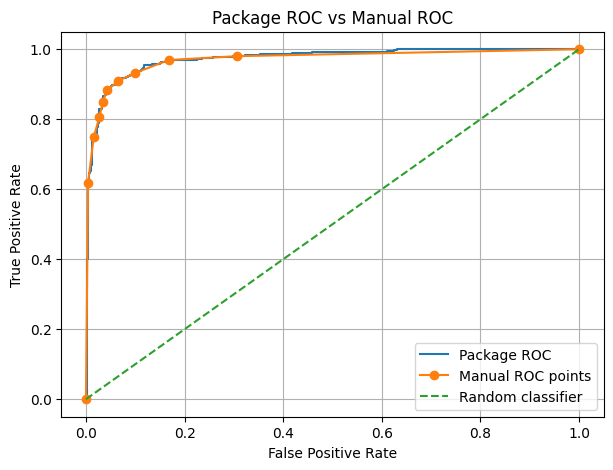

In [8]:
# manual ROC

manual_thresholds = np.arange(0, 1.01, 0.1)
manual_rows = []

for T in manual_thresholds:
    y_pred_manual = (y_test_prob >= T).astype(int)
    TP = np.sum((y_test == 1) & (y_pred_manual == 1))
    TN = np.sum((y_test == 0) & (y_pred_manual == 0))
    FP = np.sum((y_test == 0) & (y_pred_manual == 1))
    FN = np.sum((y_test == 1) & (y_pred_manual == 0))

    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

    manual_rows.append({
        "threshold": T,
        "FPR": FPR,
        "TPR": TPR
    })

manual_roc_df = pd.DataFrame(manual_rows)
print("\nManual ROC points:")
print(manual_roc_df)

plt.figure(figsize=(7, 5))
plt.plot(fpr_pkg, tpr_pkg, label="Package ROC")
plt.plot(manual_roc_df["FPR"], manual_roc_df["TPR"], marker="o", label="Manual ROC points")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Package ROC vs Manual ROC")
plt.legend()
plt.grid(True)
plt.show()

The maually generated ROC curve is less smooth than the package ROC curve because I only evaluated a small set of thresholds. The package ROC curve uses many more thresholds, so it traces the classifier's performance more precisely. To make the two ROC curves more similar, I could use more threshold values like increments of 0.01.